# COMMEMI 2D-1：固定静位移（TE 和 TM 有相同静位移） OT vs MSE 反演对比

使用 `MT2DTrueModels.create_commemi_2d1` 生成标准模型，
**通过新接口固定静位移**（`static_shift_log` + `shift_station_indices`）施加静位移。
xy 和 yx（TE/TM）在相同指定台站施加相同固定 log10 乘子 0.15。
分别用 **6D OT**（`mode="6dot"`）与 **MSE**（`mode="mse"`）反演，并对比。


In [1]:
import os
import sys
import torch
from pathlib import Path
import numpy as np

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "mt2d_inv" / "__init__.py").is_file():
            return p
    raise RuntimeError("Cannot find project root (expected src/mt2d_inv/__init__.py)")

root_path = str(_find_project_root(Path.cwd()))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from src.mt2d_inv import MT2DInverterWeightedCost, MT2DTrueModels
from src.mt2d_inv.io import ExperimentLogger
from src.mt2d_inv.plotting import (
    plot_ot_mse_convergence,
    plot_ot_mse_convergence_from_dirs,
    plot_rho_fitting_from_npz,
    plot_ot_mse_pseudosection_from_npz,
)

logger = ExperimentLogger(
    model_tag="test",
    output_root=Path("test_results"),
)
ot_run_name = "ot_21_1_both_same_te1"
mse_run_name = "mse21_1_both_same_te1"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")
print(f"Project root: {root_path}")

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.
Running on cpu
Project root: d:\文件夹文件夹\OT\MTinv_OT


In [2]:
# 1) Build COMMEMI 2D-i true model
yn, zn, nza, sig_true = MT2DTrueModels.create_commemi_2d1(
    zn=None,
    yn=None,
    nza=10,
    device=device,
    rho_host=100.0,
    rho_block=10.0,
    y_half_width_m=2000.0,
    z_top_m=10000.0,
    z_bottom_m=30000.0,
)

# 2) Survey setup
freqs = torch.logspace(0, -3.5, 15, device=device)
stations = torch.linspace(-15000.0, 15000.0, 21, device=device)

print(f"Grid (nz, ny): {(len(zn)-1, len(yn)-1)}")
print(f"Stations: {len(stations)}, Freqs: {len(freqs)}")

Grid (nz, ny): (40, 40)
Stations: 21, Freqs: 15


✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
Generating 2D MT synthetic data...
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ 2D data error propagation completed
Computing data weights (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ MSE data weights normalized (mean): scale=5.844229e+01
✓ Synthetic data generated
  -> Impedance noise level: 1.0% (gaussian)
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


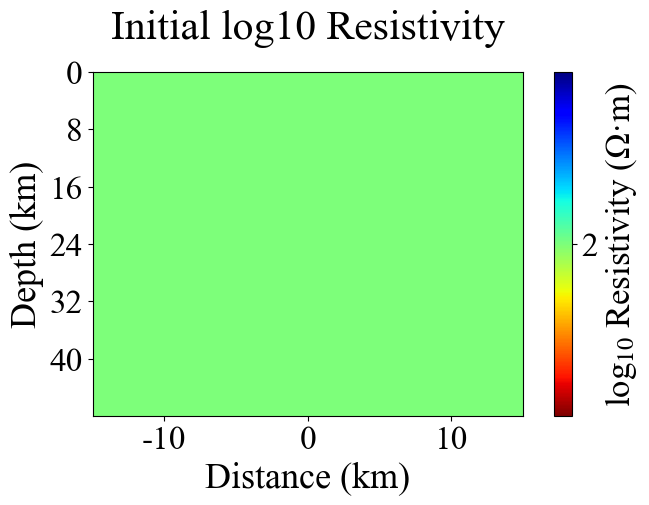

In [3]:
# 3) Inverter + synthetic data
inv = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    te_weight=1.0,
    tm_weight=1.0,
    data_loss_scale=10000,
)
inv.set_forward_operator()
inv.sig_true = sig_true
inv.create_synthetic_data(noise_level=0.01,
                        noise_type="gaussian",
                        static_shift_std=0.0,
                        shift_station_indices=[3, 10, 18],  # 显式指定台站
                        static_shift_log={"xy": 0.15, "yx": 0.15},  # 固定强度（新接口）
                        # 说明：未出现在 static_shift_log 中的模式不会被施加静位移
                        )

inv.initialize_model(initial_sigma=0.01)
inv.plot_initial_model(clip_to_stations=True, ylim=[50, 0],synthetic_figwidth_scale=2.0)


In [4]:
# 4a) OT 反演 (6dot)
inv.initialize_model(initial_sigma=0.01)
final_sigma_ot = inv.run_inversion(
    n_epochs=3,
    mode="6dot",
    progress_interval=20,
    current_lambda=1,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
print("OT inversion done")
print(final_sigma_ot.min().item(), final_sigma_ot.max().item())

✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
Epoch 1/3 [  33.3%]
  Elapsed: 0:00:03 | Remaining: ~0:00:01 | ETA: 15:02:03
  Epoch time: 0.91s | Avg: 0.91s
  Total: 1.3689e+01 | Data(6dot): 1.3689e+01
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 9.571 | Rough: 0.00e+00 | Lam: 1.0000000
  OT-distance(6D, view-only): 1.368939e+00
  GradNorms: |g_d|=nan | |λ·g_m|=nan
Epoch 3/3 [ 100.0%]
  Elapsed: 0:00:05 | Remaining: ~0:00:00 | ETA: 15:02:03
  Epoch time: 1.04s | Avg: 0.96s
  Total: 8.7817e+00 | Data(6dot): 8.5317e+00
  Misfit(RMS χ²): 8.569 | Rough: 2.50e-01 | Lam: 1.0000000
  OT-distance(6D, view-only): 8.531722e-01
  GradNorms: |g_d|=nan | |λ·g_m|=nan
Inversion completed.
OT inversion done
1e-10 0.010943373084074226


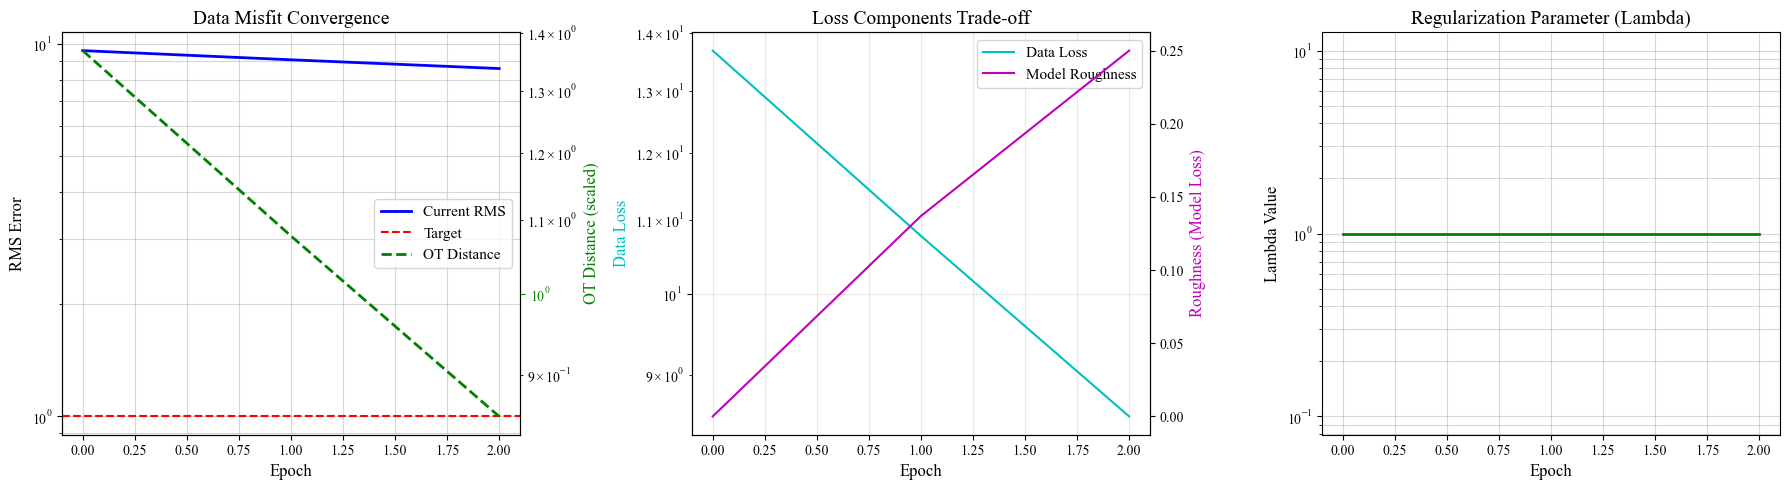

Model structural similarity (SSIM): 0.6701


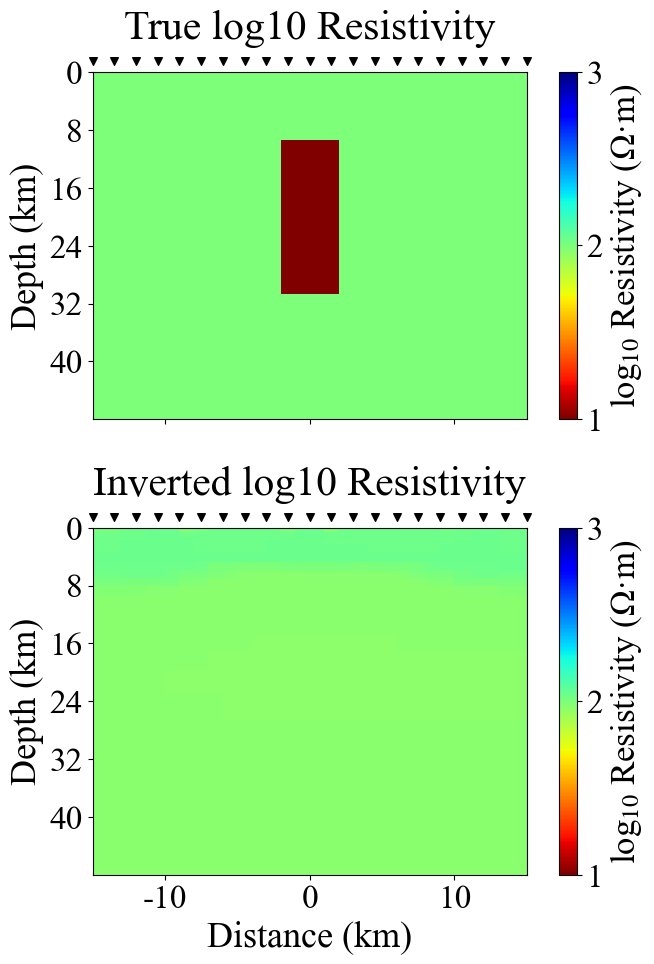

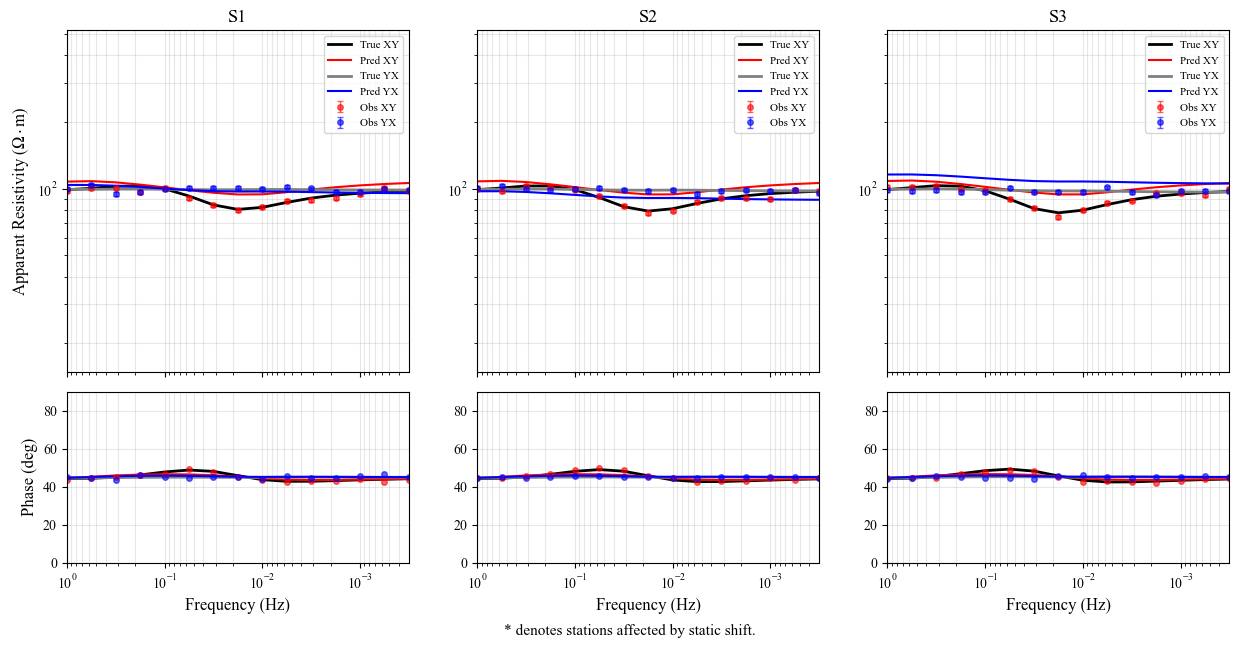

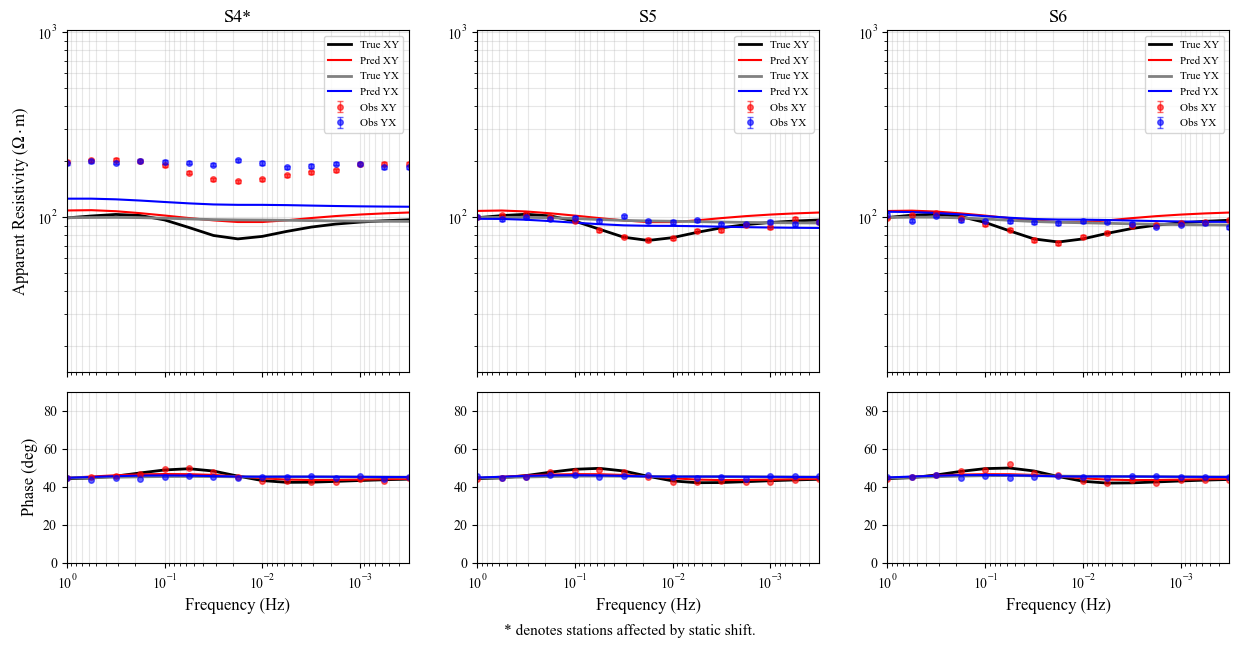

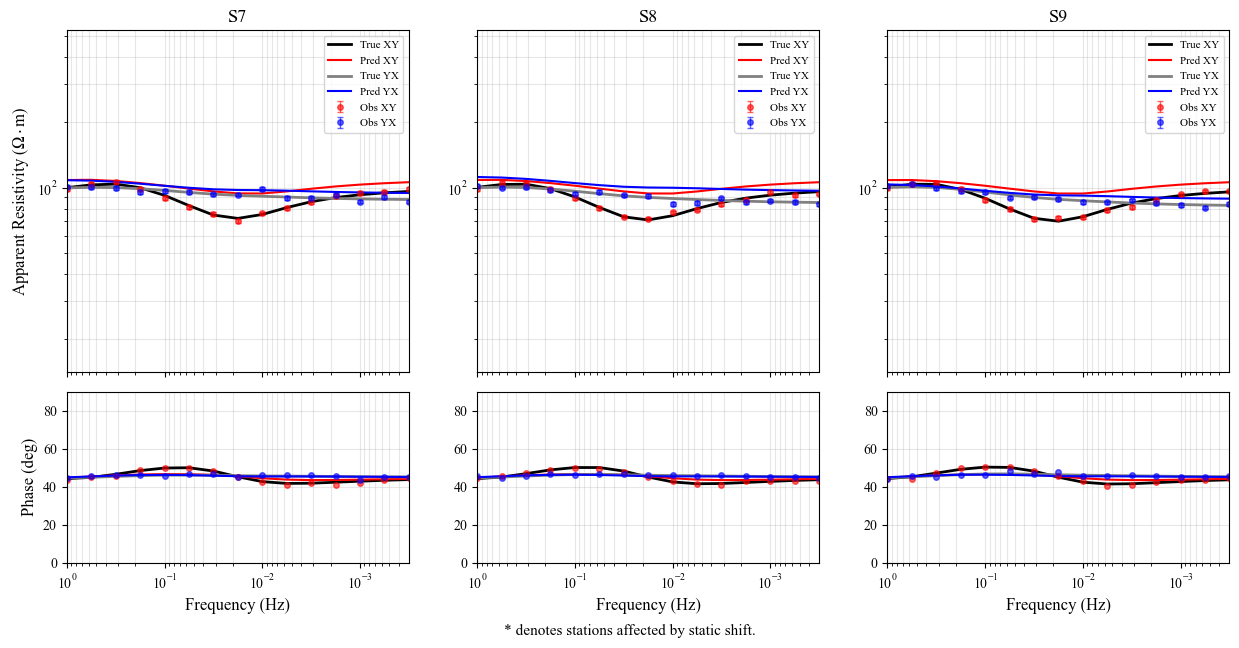

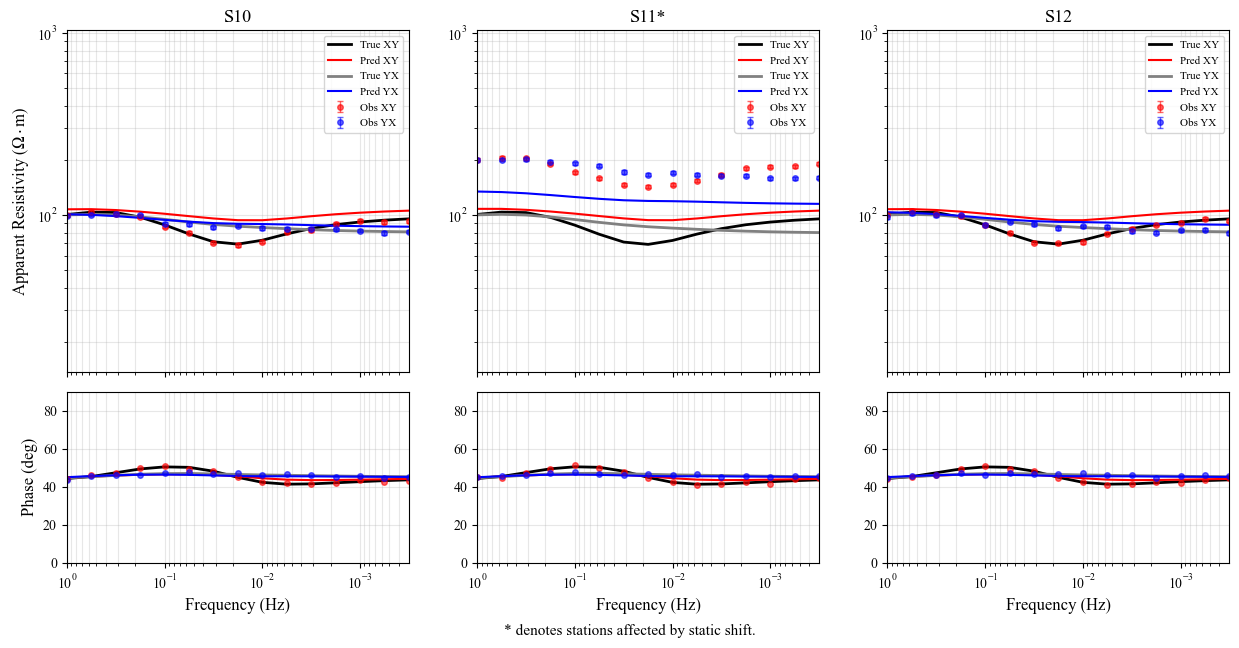

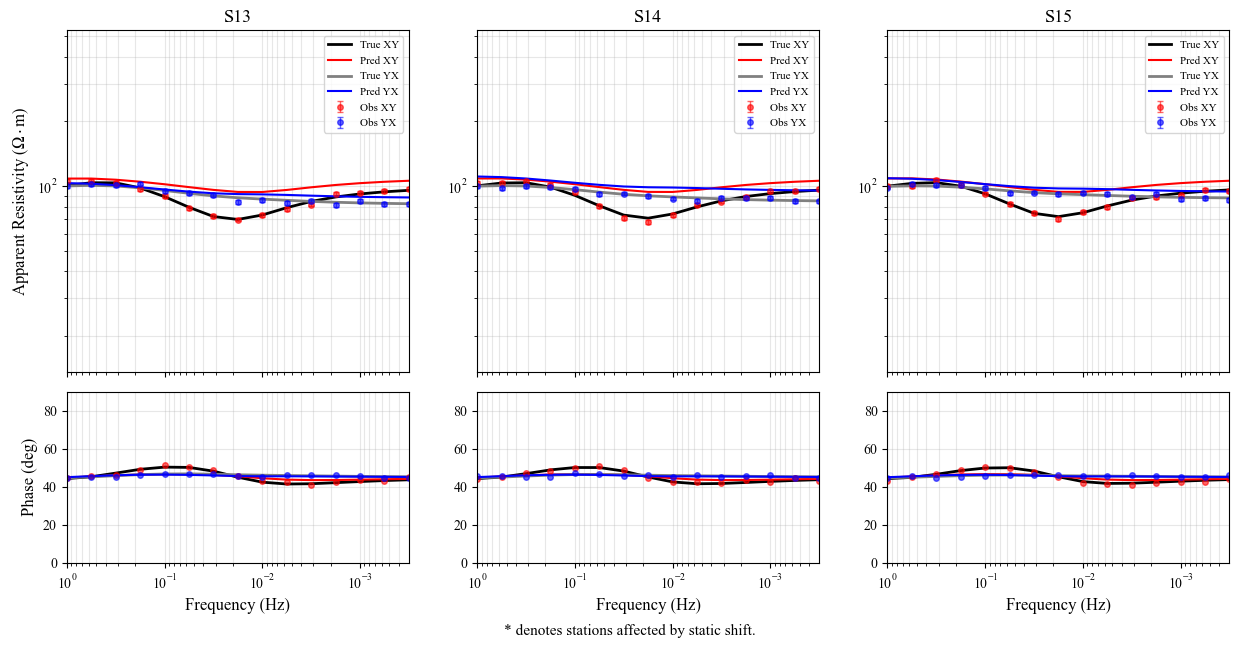

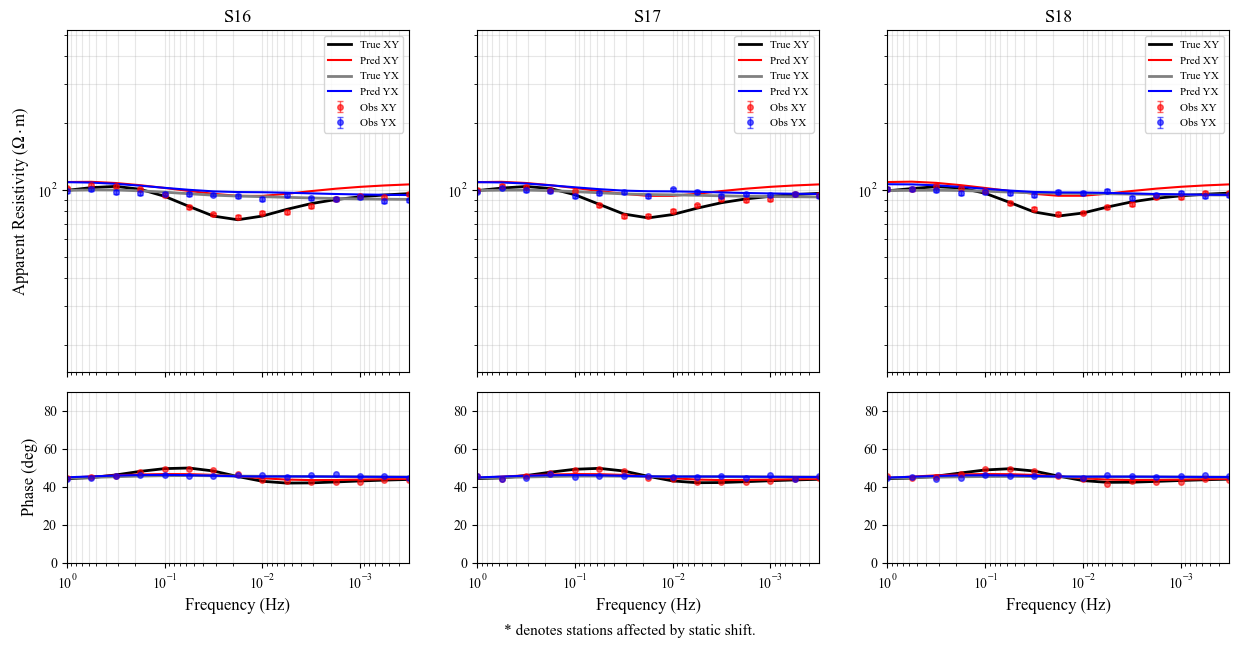

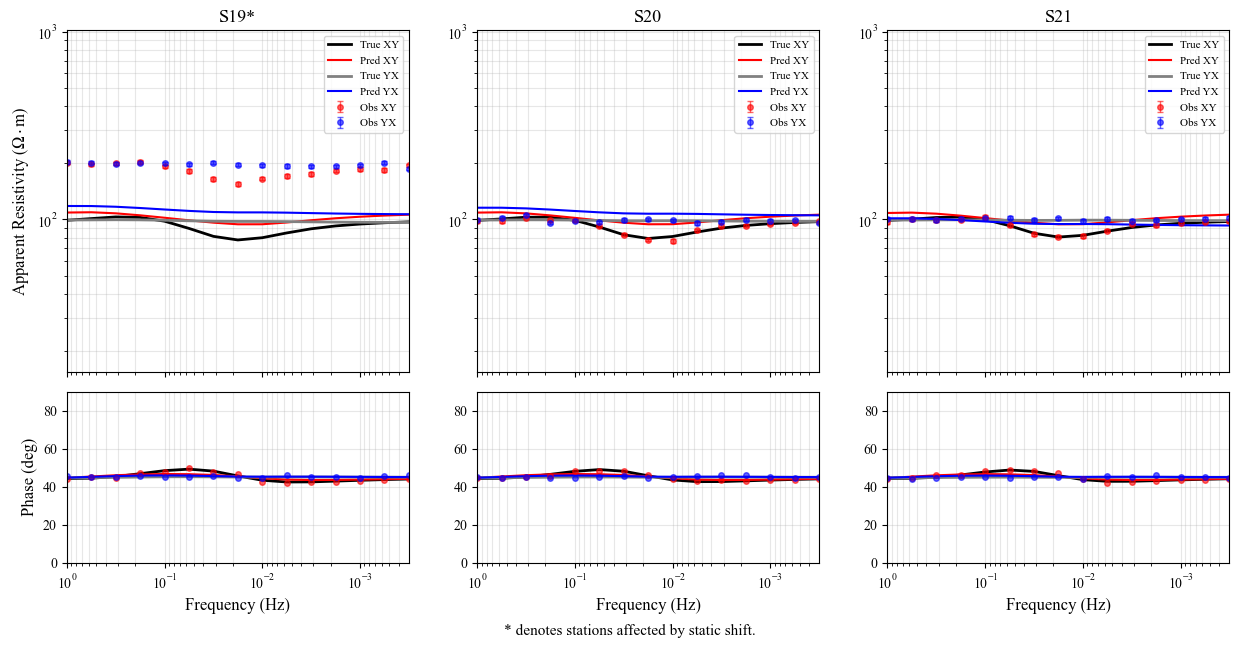

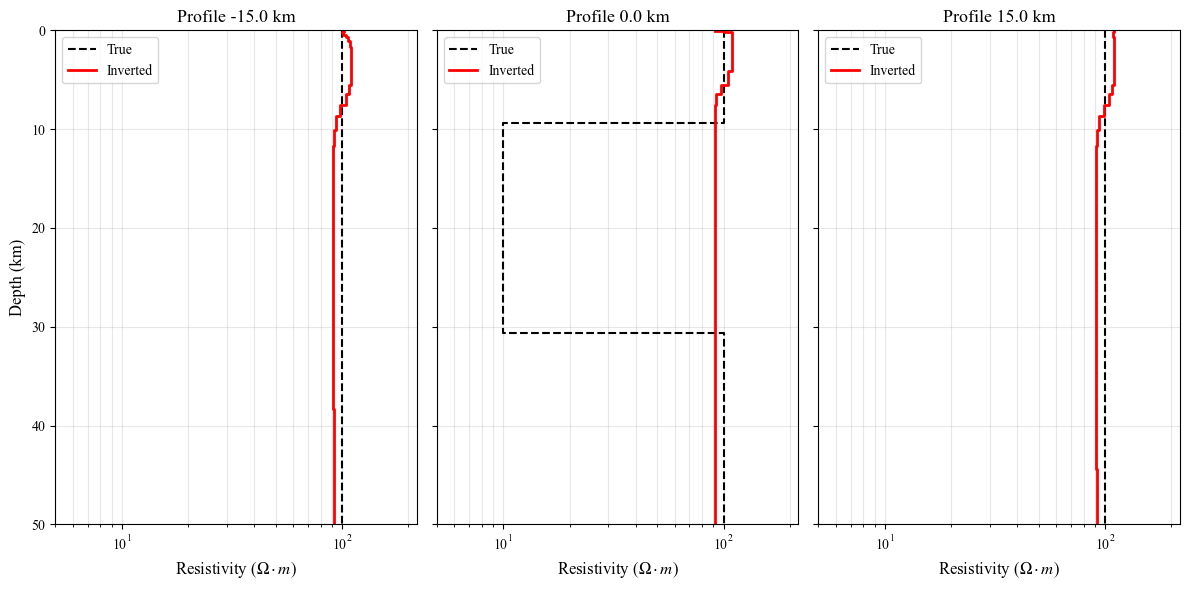

d:\文件夹文件夹\OT\MTinv_OT\src\mt2d_inv\plotting\inversion.py:594: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Times New Roman.
  plt.tight_layout()
d:\miniconda3\envs\pytorch_gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


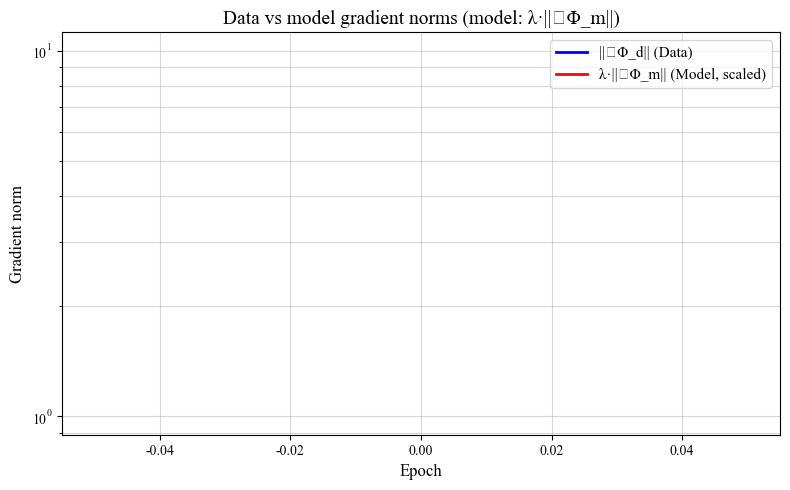

In [5]:
# 5a) OT 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
inv.plot_data_fitting(plot_true_data=True)
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [ ]:
# 6a) 保存 OT 结果
ot_run_dir = logger.save_from_inverter(inv, run_name=ot_run_name)
history_ot = list(inv.loss_history)
print(f"OT run saved: {ot_run_dir}")



Saving results to: test_results\test\2026-07-11_15-02-14_ot_21_1_both_same_te1
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz


d:\文件夹文件夹\OT\MTinv_OT\src\mt2d_inv\io\experiment.py:389: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Times New Roman.
  plt.tight_layout()
d:\文件夹文件夹\OT\MTinv_OT\src\mt2d_inv\io\experiment.py:390: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Times New Roman.
  fig.savefig(figures_dir / "gradient_history.png", dpi=300, bbox_inches='tight')


Model structural similarity (SSIM): 0.6701


✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m
✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
Generating 2D MT synthetic data...
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ 2D data error propagation completed
Computing data weights (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ MSE data weights normalized (mean): scale=5.844229e+01
✓ Synthetic data generated
  -> Impedance noise level: 1.0% (gaussian)
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


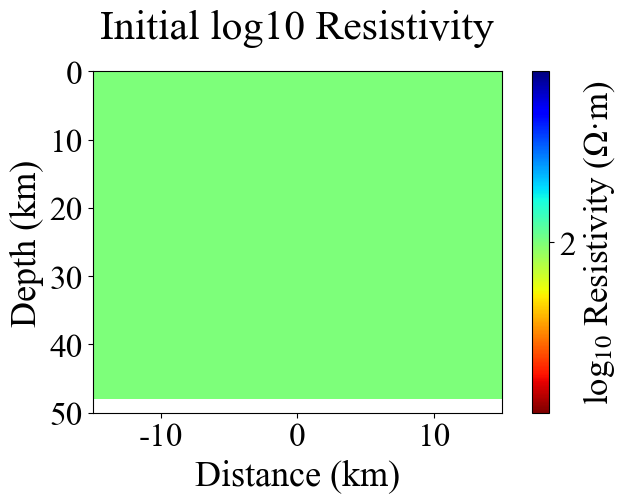

✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
Epoch 1/3 [  33.3%]
  Elapsed: 0:00:00 | Remaining: ~0:00:01 | ETA: 17:25:57
  Epoch time: 0.58s | Avg: 0.58s
  Total: 8.0468e-01 | Data(mse): 8.0468e-01
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 9.571 | Rough: 0.00e+00 | Lam: 0.1000000
  OT-distance(6D, view-only): 1.368939e+00
  GradNorms: |g_d|=nan | |λ·g_m|=nan
Epoch 3/3 [ 100.0%]
  Elapsed: 0:00:01 | Remaining: ~0:00:00 | ETA: 17:25:57
  Epoch time: 0.50s | Avg: 0.51s
  Total: 6.0971e-01 | Data(mse): 5.8927e-01
  Misfit(RMS χ²): 8.191 | Rough: 2.04e-01 | Lam: 0.1000000
  OT-distance(6D, view-only): 1.012443e+00
  GradNorms: |g_d|=nan | |λ·g_m|=nan
Inversion completed.
MSE inversion done
1e-10 0.010943320708819586


In [ ]:
# 4b) MSE 反演（同一静位移观测数据，重置初模）
inv.initialize_model(initial_sigma=0.01)

inv = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    data_loss_scale=30,
)
inv.set_forward_operator()
inv.sig_true = sig_true
inv.create_synthetic_data(noise_level=0.01,
                        noise_type="gaussian",
                        static_shift_std=0.0,
                        shift_station_indices=[3, 10, 18],  # 显式指定台站
                        static_shift_log={"xy": 0.15, "yx": 0.15},  # 固定强度（新接口）
                        # 说明：未出现在 static_shift_log 中的模式不会被施加静位移
                        )

inv.initialize_model(initial_sigma=0.01)
inv.plot_initial_model(clip_to_stations=True, ylim=[50, 0],synthetic_figwidth_scale=2.0)

final_sigma_mse = inv.run_inversion(
    n_epochs=3,
    mode="mse",
    progress_interval=20,
    current_lambda=0.1,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
print("MSE inversion done")
print(final_sigma_mse.min().item(), final_sigma_mse.max().item())

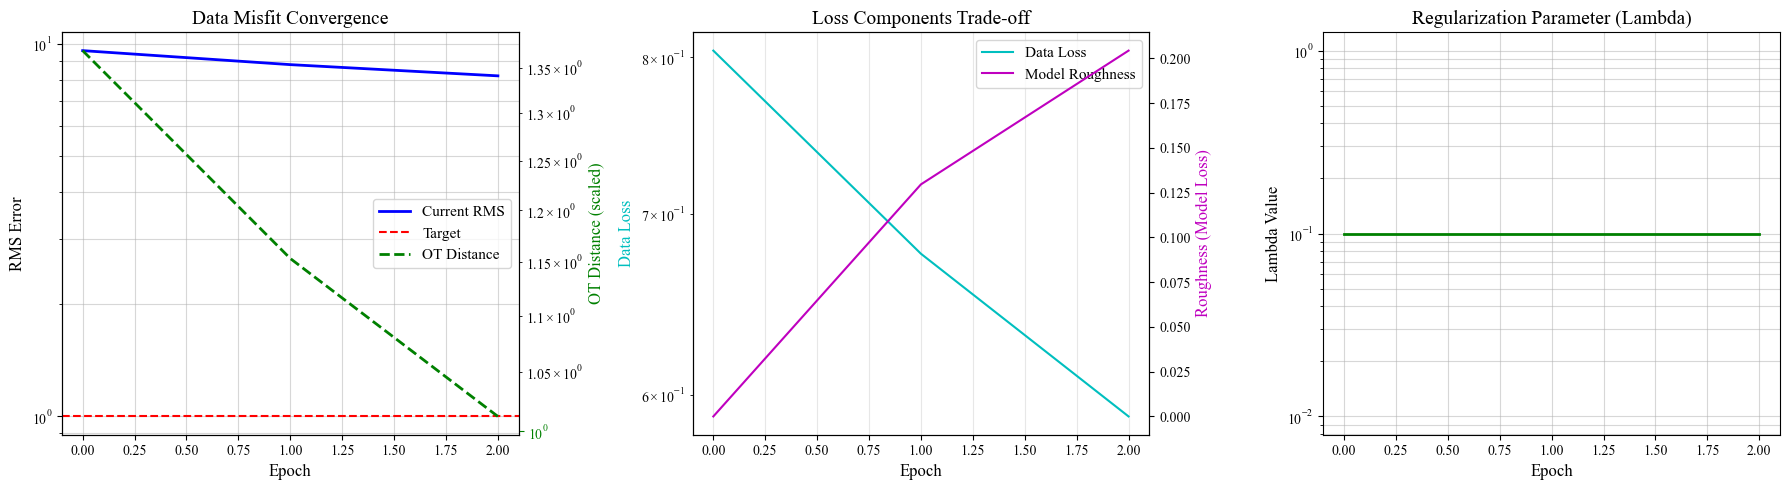

Model structural similarity (SSIM): 0.5960


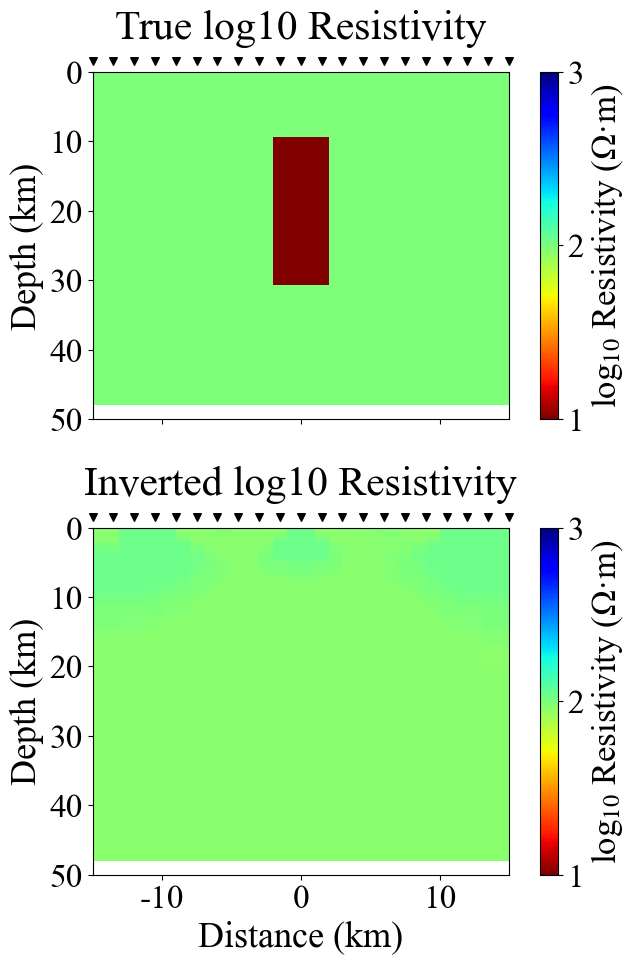

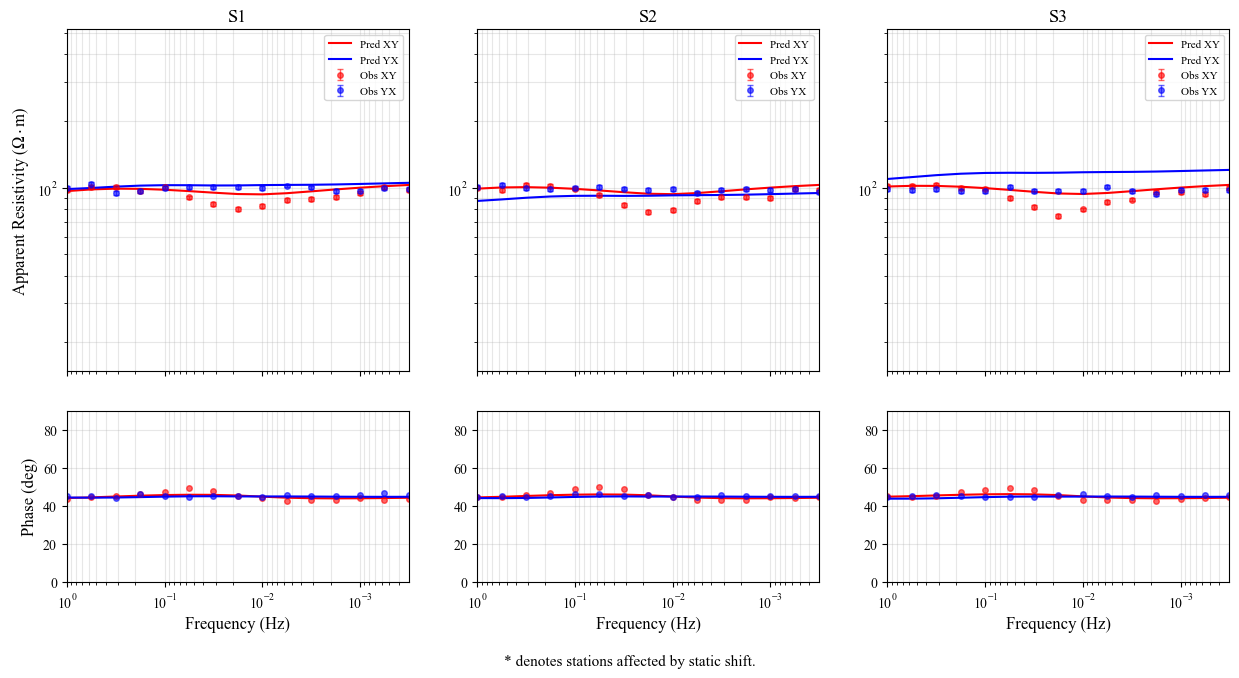

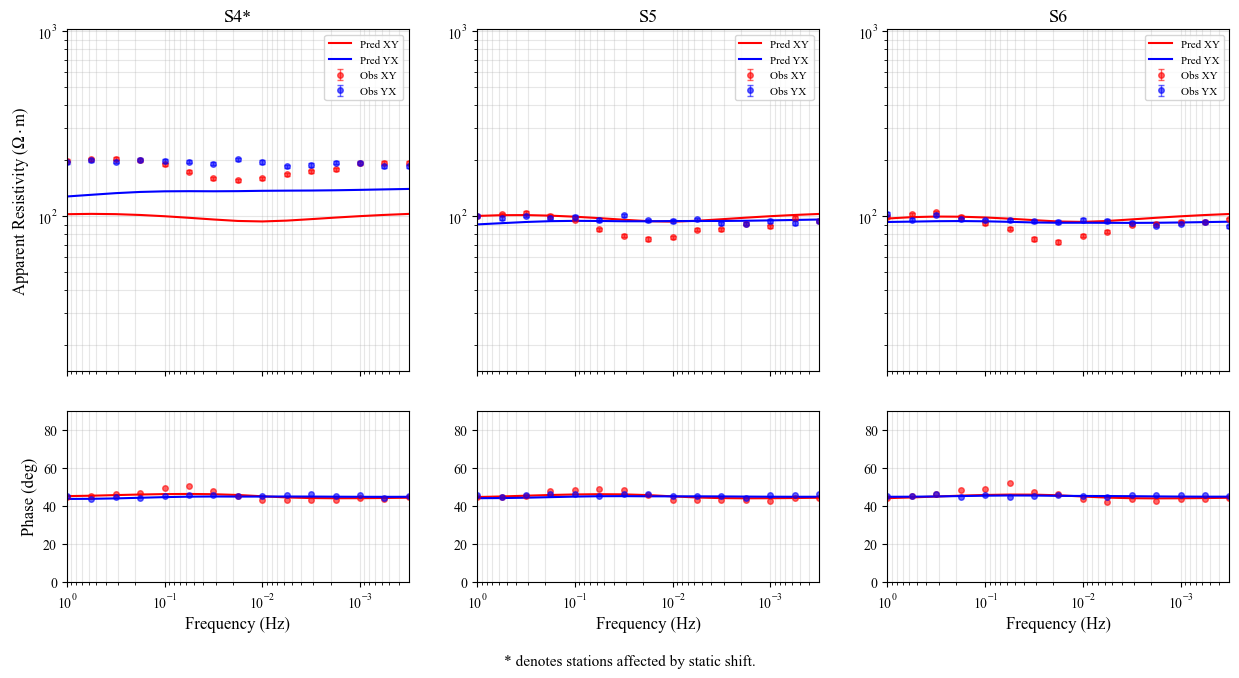

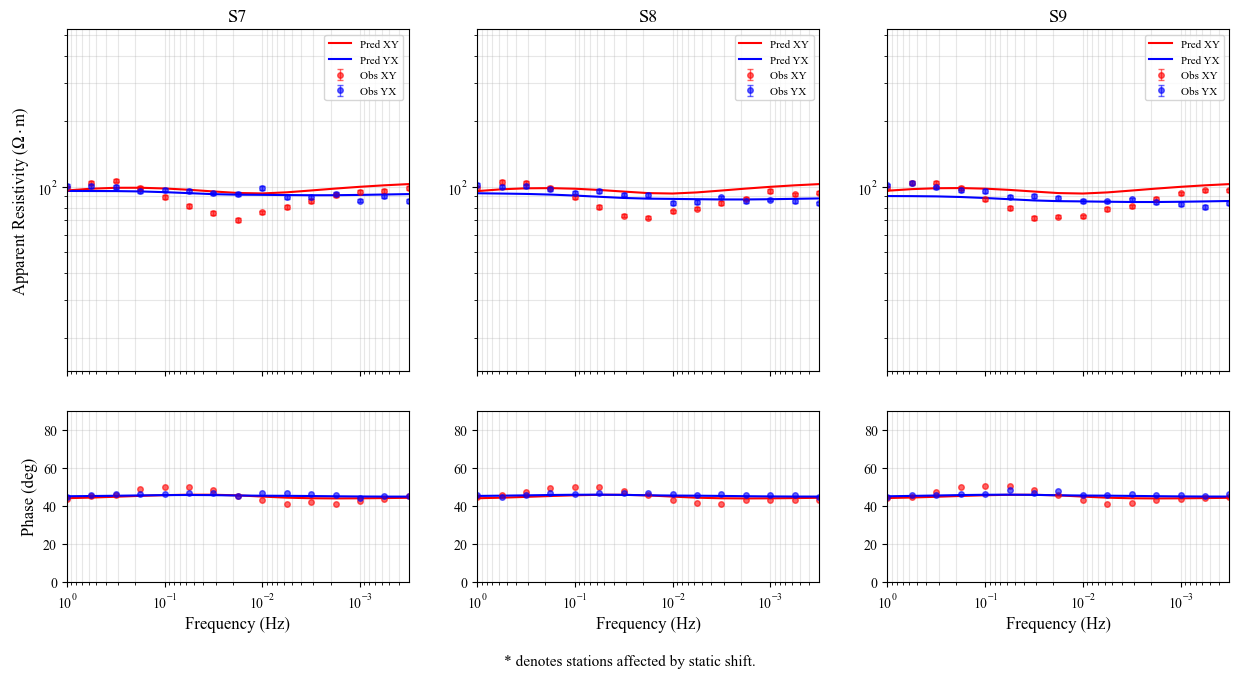

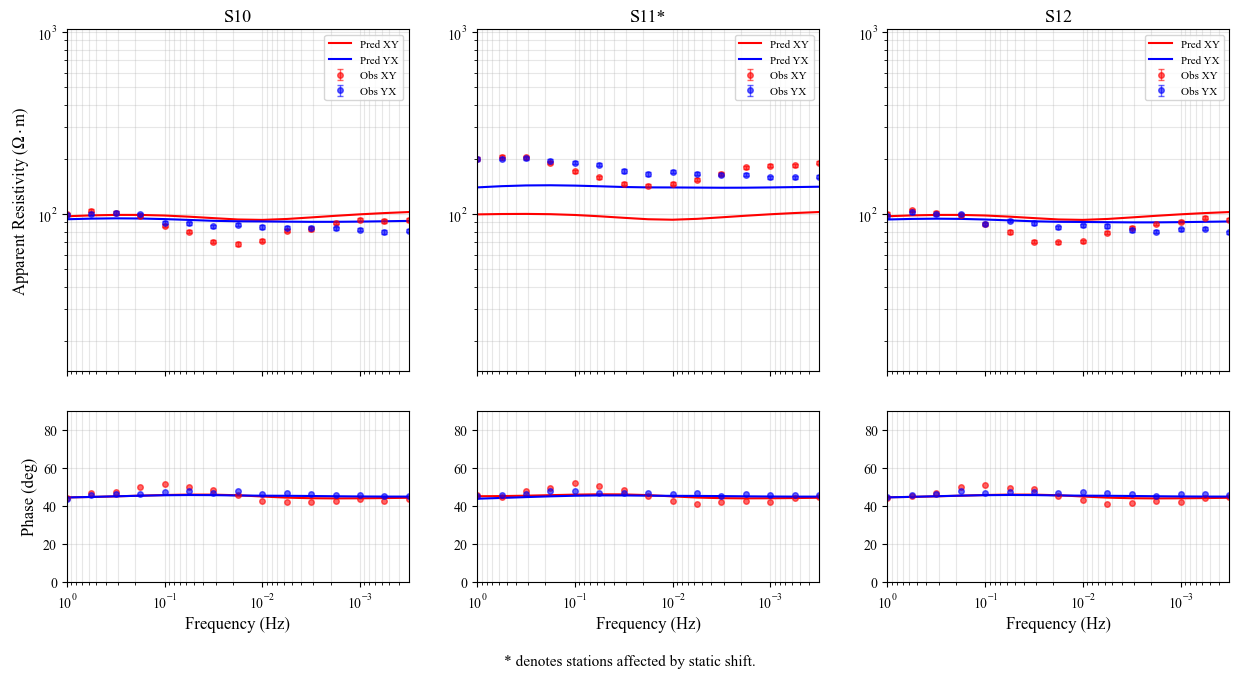

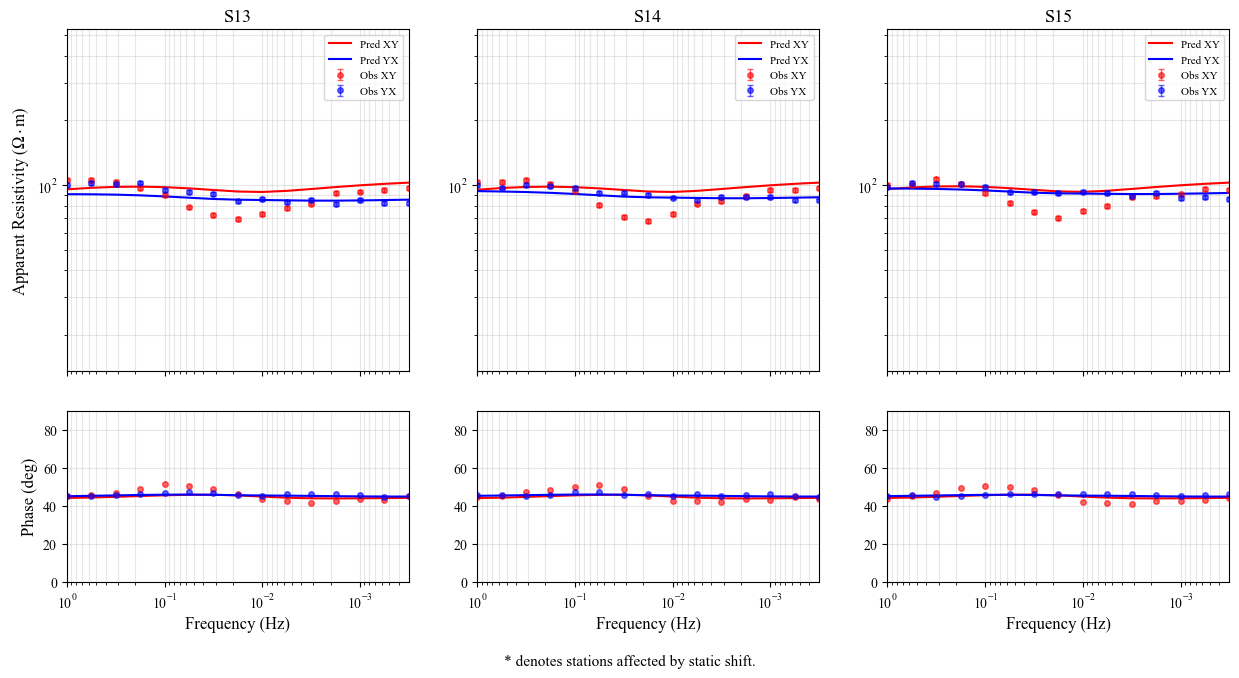

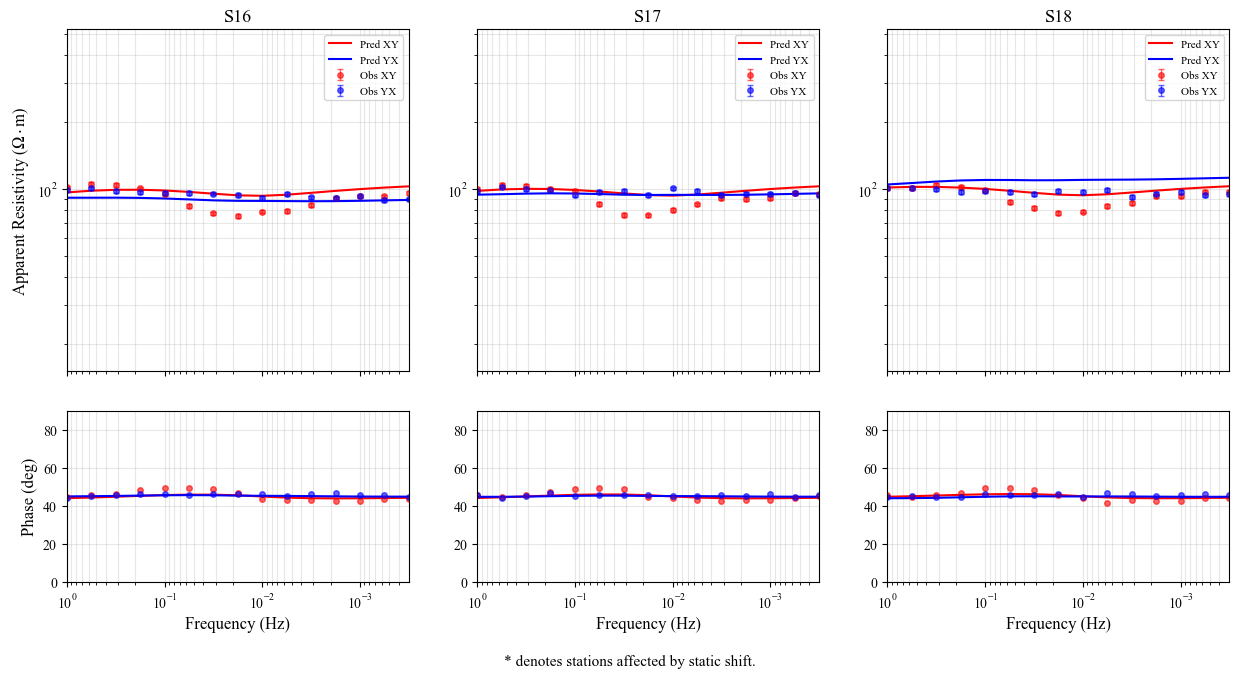

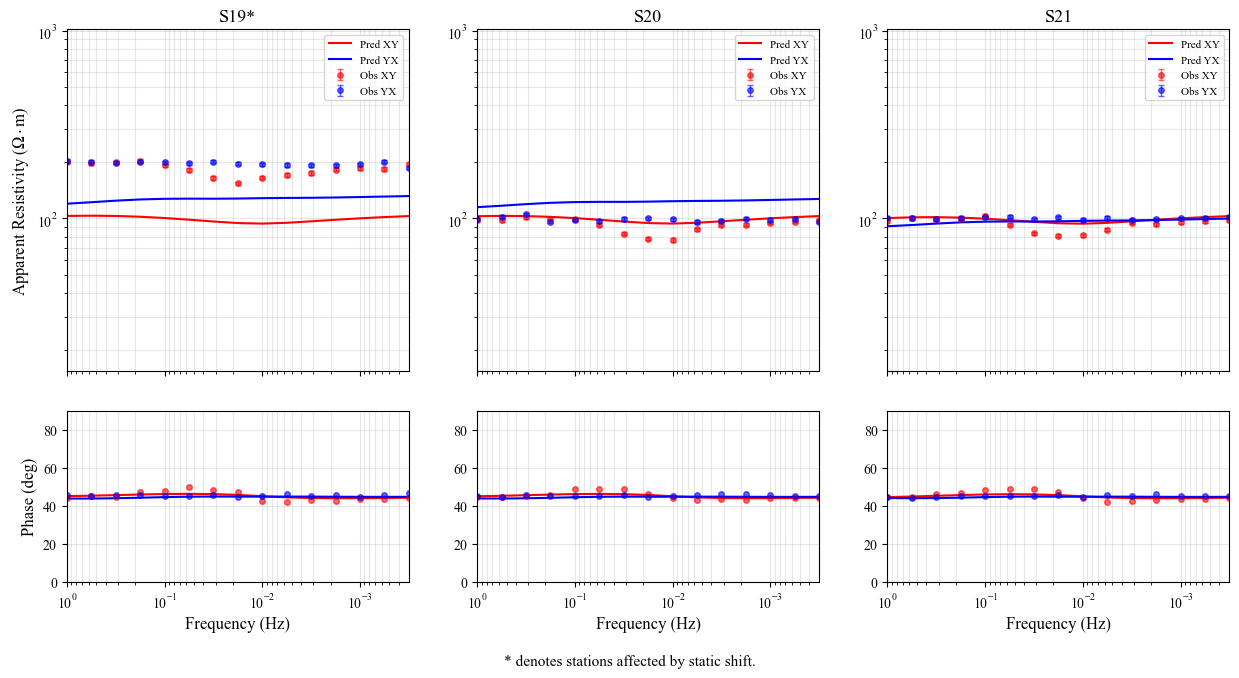

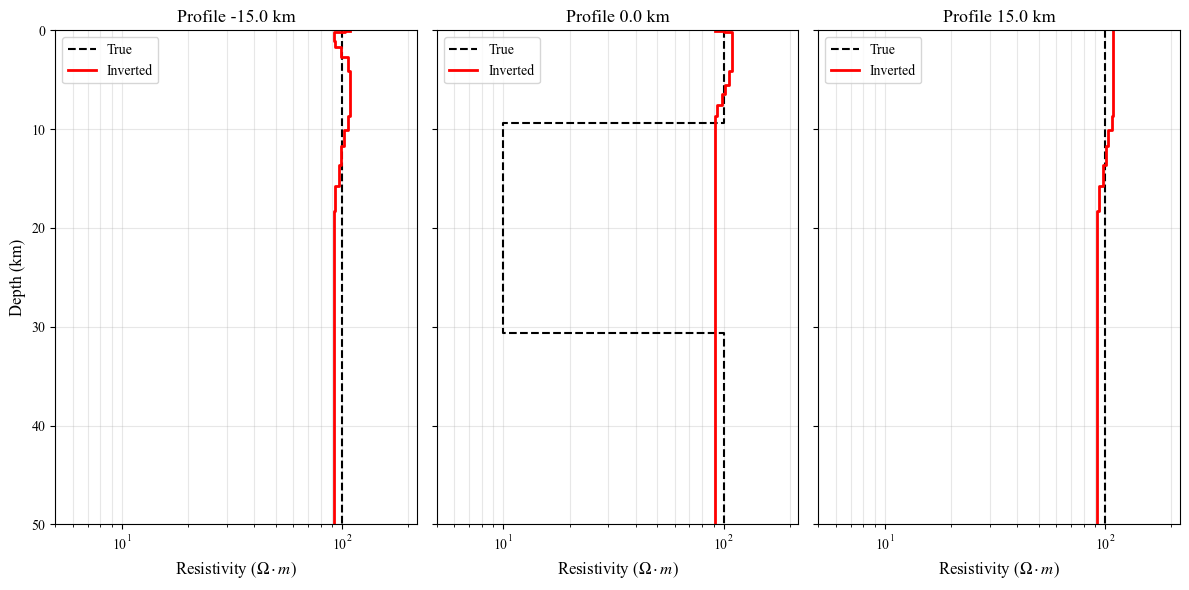

d:\文件夹文件夹\OT\MTinv_OT\src\mt2d_inv\plotting\inversion.py:561: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Times New Roman.
  plt.tight_layout()
d:\miniconda3\envs\pytorch_gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


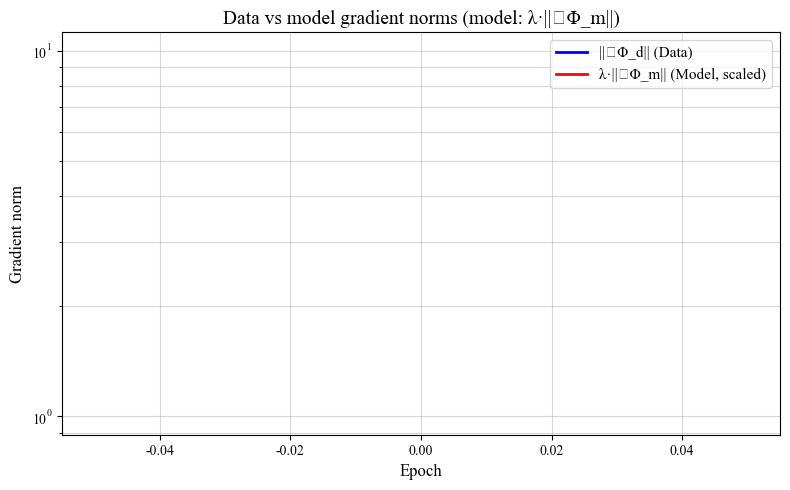

In [ ]:
# 5b) MSE 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
inv.plot_data_fitting()
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [ ]:
# 6b) 保存 MSE 结果
mse_run_dir = logger.save_from_inverter(inv, run_name=mse_run_name)
history_mse = list(inv.loss_history)
print(f"MSE run saved: {mse_run_dir}")



Saving results to: test_results\test\2026-07-09_17-26-06_mse21_1_both_same_te1
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz


d:\文件夹文件夹\OT\MTinv_OT\src\mt2d_inv\io\experiment.py:389: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Times New Roman.
  plt.tight_layout()
d:\文件夹文件夹\OT\MTinv_OT\src\mt2d_inv\io\experiment.py:390: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Times New Roman.
  fig.savefig(figures_dir / "gradient_history.png", dpi=300, bbox_inches='tight')


Model structural similarity (SSIM): 0.5960


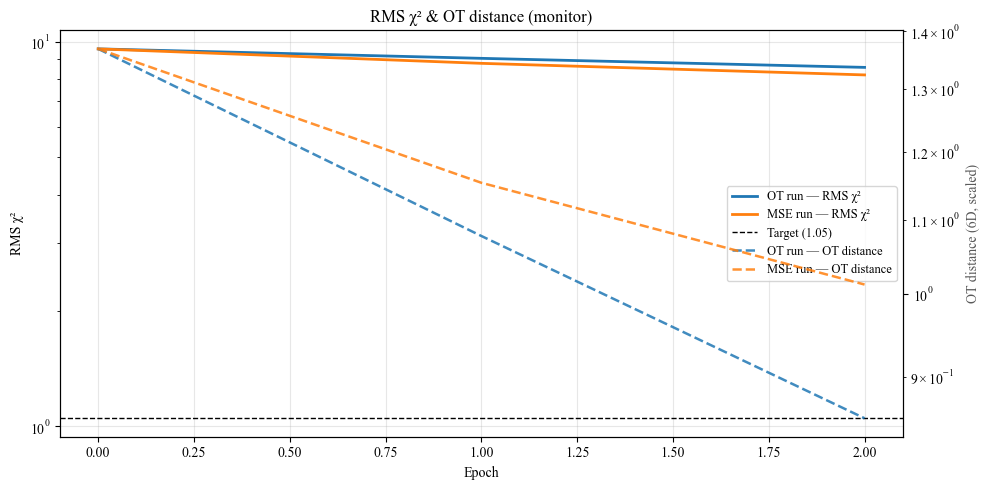

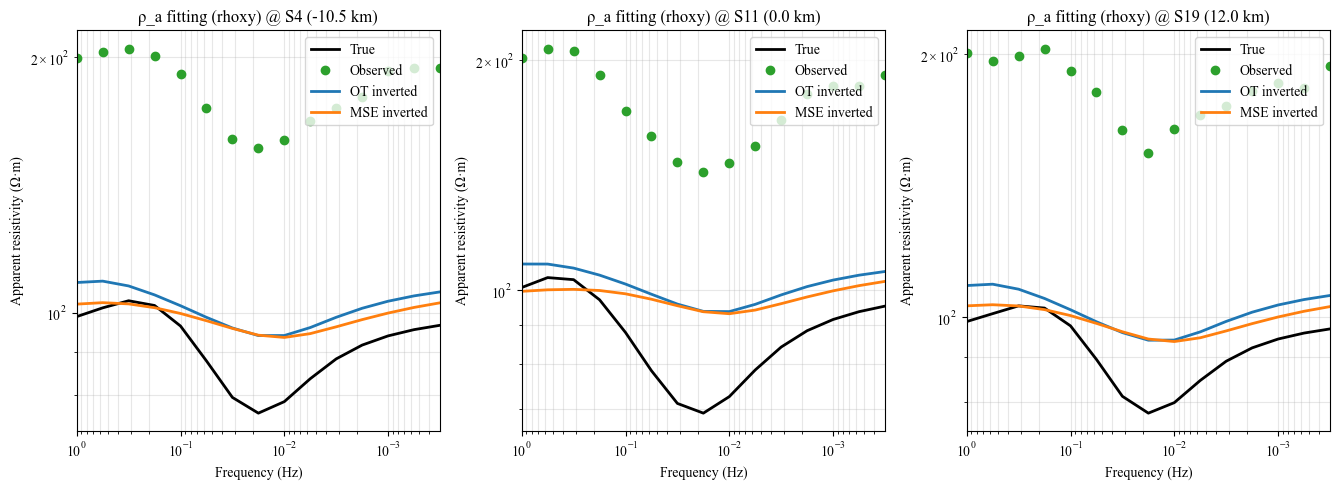

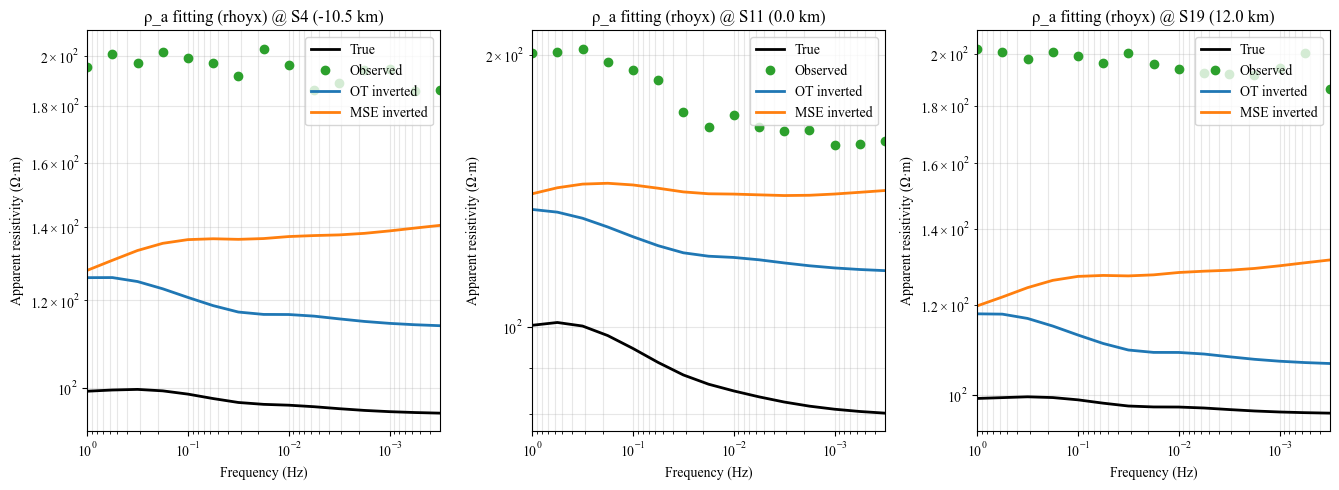

d:\文件夹文件夹\OT\MTinv_OT\src\mt2d_inv\plotting\pseudosection.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


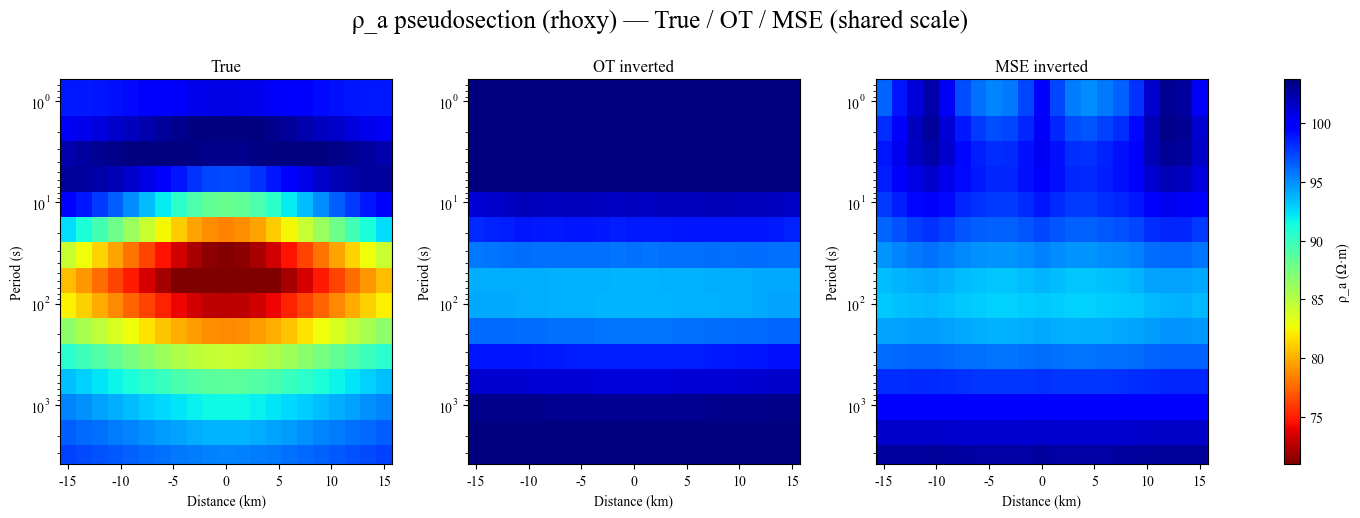

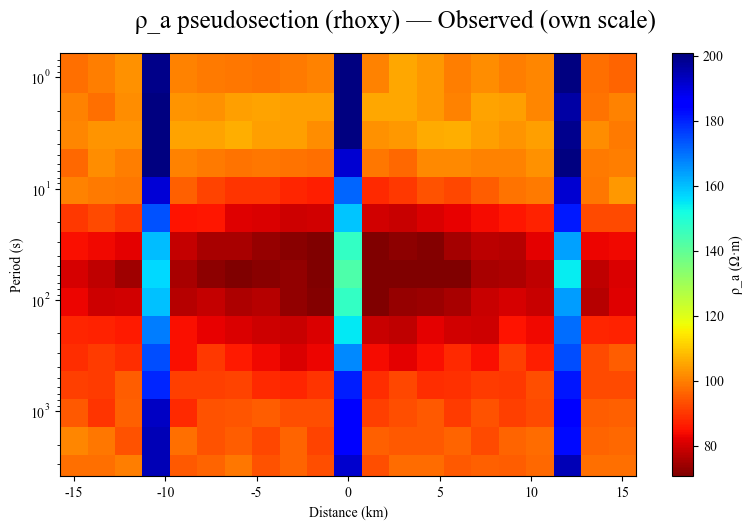

{'inversion_axes': array([<Axes: title={'center': 'True'}, xlabel='Distance (km)', ylabel='Period (s)'>,
        <Axes: title={'center': 'OT inverted'}, xlabel='Distance (km)', ylabel='Period (s)'>,
        <Axes: title={'center': 'MSE inverted'}, xlabel='Distance (km)', ylabel='Period (s)'>],
       dtype=object),
 'observed_axes': <Axes: xlabel='Distance (km)', ylabel='Period (s)'>}

In [ ]:
# 7) OT vs MSE 对比（收敛曲线 + 视电阻率四线合一 + 伪断面）
plot_ot_mse_convergence(history_ot, history_mse, target_misfit=1.05)

plot_rho_fitting_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    station_idx=[3, 10, 18],
    mode="xy",
)
plot_rho_fitting_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    station_idx=[3, 10, 18],
    mode="yx",
)

plot_ot_mse_pseudosection_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    mode="xy",
)